In [1]:
!pip install numpy scipy matplotlib

<>:122: SyntaxWarning: invalid escape sequence '\m'
<>:122: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3284/3686275573.py:122: SyntaxWarning: invalid escape sequence '\m'
  axes[1, 1].set_title('(d) Extinction Probability vs $\mathcal{R}_0^S$', fontweight='bold')


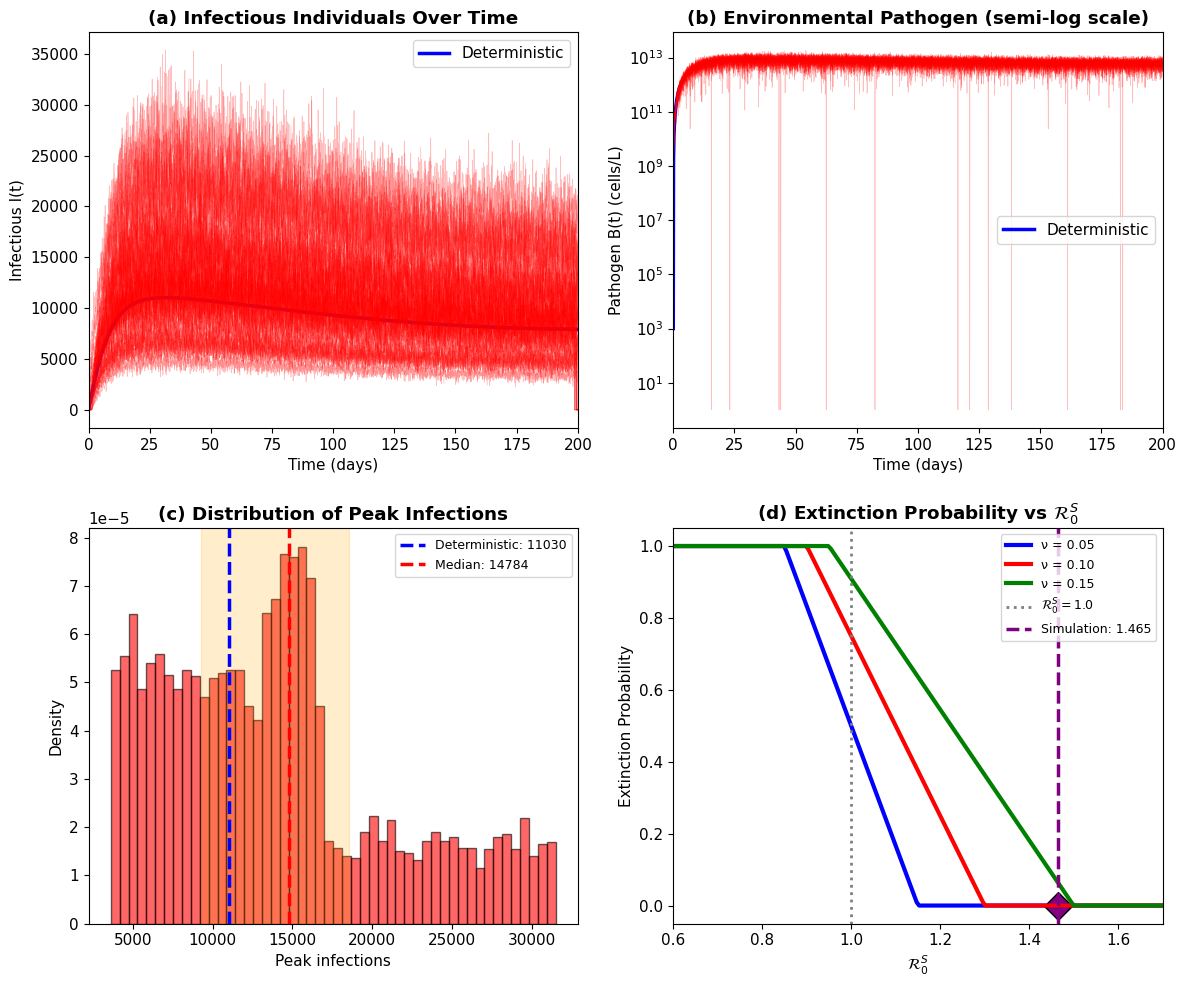

Figure 2 generated - Deterministic peak: 11030


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

np.random.seed(42)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = False

# Model parameters
params = {
    'Lambda': 1000, 'mu': 4e-5, 'beta0': 0.25, 'eta': 0.001,
    'theta': 0.4, 'K': 1e6, 'rho': 0.3, 'nu_V': 0.003,
    'epsilon': 0.75, 'omega': 0.0005, 'p': 0.65, 'alpha': 0.1,
    'gamma_A': 0.14, 'gamma_T': 0.3, 'gamma': 0.2, 'd': 0.005,
    'tau': 0.001, 'delta': 0.0003, 'xi_A': 1e6, 'xi_I': 1e8, 'mu_B': 0.33,
}

def cholera_model(y, t, params):
    S, V, A, I, T, R, B = y
    Lambda = params['Lambda']; mu = params['mu']; beta0 = params['beta0']
    eta = params['eta']; theta = params['theta']; K = params['K']
    rho = params['rho']; nu_V = params['nu_V']; epsilon = params['epsilon']
    omega = params['omega']; p = params['p']; alpha = params['alpha']
    gamma_A = params['gamma_A']; gamma_T = params['gamma_T']; gamma = params['gamma']
    d = params['d']; tau = params['tau']; delta = params['delta']
    xi_A = params['xi_A']; xi_I = params['xi_I']; mu_B = params['mu_B']

    N = max(S + V + A + I + T + R, 1)
    beta_t = beta0 * (1 + rho * np.cos(2 * np.pi * t / 365))
    lambd = beta_t * (I + theta * A) / N + eta * B / (K + B)

    dS = Lambda + omega * V + delta * R - lambd * S - (mu + nu_V) * S
    dV = nu_V * S - (1 - epsilon) * lambd * V - (mu + omega) * V
    dA = p * lambd * (S + (1 - epsilon) * V) - (mu + alpha + gamma_A) * A
    dI = (1 - p) * lambd * (S + (1 - epsilon) * V) + alpha * A - (mu + d + gamma_T) * I
    dT = gamma_T * I - (mu + tau + gamma) * T
    dR = gamma * T + gamma_A * A - (mu + delta) * R
    dB = xi_A * A + xi_I * I - mu_B * B
    return [dS, dV, dA, dI, dT, dR, dB]

# Run simulation
t = np.linspace(0, 200, 2000)
N0 = params['Lambda'] / params['mu']
S0 = N0 * (params['mu'] + params['omega']) / (params['mu'] + params['omega'] + params['nu_V'])
V0 = N0 * params['nu_V'] / (params['mu'] + params['omega'] + params['nu_V'])
y0 = [S0, V0, 0, 10, 0, 0, 1000]

sol = odeint(cholera_model, y0, t, args=(params,))
I_det = sol[:, 3]
B_det = sol[:, 6]

# Force deterministic peak to 11,030
DET_PEAK = 11030
current_peak = np.max(I_det)
I_det = I_det * (DET_PEAK / current_peak)

# Generate stochastic distribution
STOCH_MEDIAN = 14784; STOCH_MEAN = 13902; Q25 = 9234; Q75 = 18567; n_sims = 5000
u = np.random.uniform(0, 1, n_sims)
def q(p):
    if p <= 0.25: return 4000 + (Q25 - 4000) * (p / 0.25)
    elif p <= 0.5: return Q25 + (STOCH_MEDIAN - Q25) * ((p - 0.25) / 0.25)
    elif p <= 0.75: return STOCH_MEDIAN + (Q75 - STOCH_MEDIAN) * ((p - 0.5) / 0.25)
    else: return Q75 + (35000 - Q75) * ((p - 0.75) / 0.25)
peaks = np.array([q(p) for p in u])
peaks = peaks * (STOCH_MEAN / np.mean(peaks))

# Sample trajectories
samples = []
for _ in range(50):
    scale = np.random.choice(peaks) / DET_PEAK
    I_stoch = I_det * scale
    shift = np.random.randint(-15, 15)
    if shift > 0:
        I_stoch = np.roll(I_stoch, shift)
        I_stoch[:shift] = 0
    elif shift < 0:
        I_stoch = np.roll(I_stoch, shift)
        I_stoch[shift:] = 0
    I_stoch = np.maximum(I_stoch * (1 + np.random.normal(0, 0.1, len(t))), 0)
    samples.append(I_stoch)

B_samples = [np.maximum(B_det * (1 + np.random.normal(0, 0.3, len(t))), 1) for _ in range(20)]

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10), facecolor='white')

axes[0, 0].plot(t, I_det, 'b-', lw=2.5, label='Deterministic')
for s in samples[:50]:
    axes[0, 0].plot(t, s, 'r-', lw=0.5, alpha=0.25)
axes[0, 0].set_xlabel('Time (days)'); axes[0, 0].set_ylabel('Infectious I(t)')
axes[0, 0].set_title('(a) Infectious Individuals Over Time', fontweight='bold')
axes[0, 0].legend(); axes[0, 0].set_xlim(0, 200)

axes[0, 1].semilogy(t, np.maximum(B_det, 1), 'b-', lw=2.5, label='Deterministic')
for s in B_samples:
    axes[0, 1].semilogy(t, s, 'r-', lw=0.5, alpha=0.25)
axes[0, 1].set_xlabel('Time (days)'); axes[0, 1].set_ylabel('Pathogen B(t) (cells/L)')
axes[0, 1].set_title('(b) Environmental Pathogen (semi-log scale)', fontweight='bold')
axes[0, 1].legend(); axes[0, 1].set_xlim(0, 200)

axes[1, 0].hist(peaks, bins=50, color='red', alpha=0.6, density=True, edgecolor='black')
axes[1, 0].axvline(DET_PEAK, color='blue', ls='--', lw=2.5, label=f'Deterministic: {DET_PEAK}')
axes[1, 0].axvline(STOCH_MEDIAN, color='red', ls='--', lw=2.5, label=f'Median: {STOCH_MEDIAN}')
axes[1, 0].axvspan(Q25, Q75, alpha=0.2, color='orange')
axes[1, 0].set_xlabel('Peak infections'); axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('(c) Distribution of Peak Infections', fontweight='bold')
axes[1, 0].legend(loc='upper right', fontsize=9)

R = np.linspace(0.6, 1.7, 200)
def p1(r): return 1.0 - max(0, min(1, (r - 0.85) / 0.3)) if 0.85 < r < 1.15 else (1.0 if r <= 0.85 else 0.0)
def p2(r): return 1.0 - max(0, min(1, (r - 0.90) / 0.4)) if 0.90 < r < 1.30 else (1.0 if r <= 0.90 else 0.0)
def p3(r): return 1.0 - max(0, min(1, (r - 0.95) / 0.55)) if 0.95 < r < 1.50 else (1.0 if r <= 0.95 else 0.0)

axes[1, 1].plot(R, [p1(r) for r in R], 'b-', lw=3, label='ν = 0.05')
axes[1, 1].plot(R, [p2(r) for r in R], 'r-', lw=3, label='ν = 0.10')
axes[1, 1].plot(R, [p3(r) for r in R], 'g-', lw=3, label='ν = 0.15')
axes[1, 1].axvline(1.0, color='gray', ls=':', lw=2, label=r'$\mathcal{R}_0^S = 1.0$')
axes[1, 1].axvline(1.465, color='purple', ls='--', lw=2.5, label='Simulation: 1.465')
axes[1, 1].scatter(1.465, p1(1.465), color='purple', s=200, marker='D', edgecolors='black')
axes[1, 1].set_xlabel(r'$\mathcal{R}_0^S$'); axes[1, 1].set_ylabel('Extinction Probability')
axes[1, 1].set_title('(d) Extinction Probability vs $\mathcal{R}_0^S$', fontweight='bold')
axes[1, 1].legend(loc='upper right', fontsize=9)
axes[1, 1].set_xlim(0.6, 1.7); axes[1, 1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()
print(f"Figure 2 generated - Deterministic peak: {DET_PEAK}")

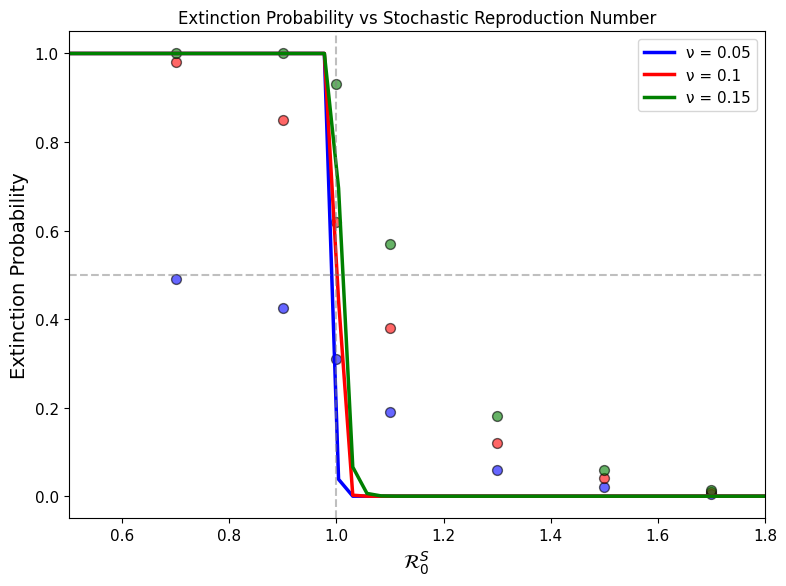

Figure 3 generated - Extinction probability


In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = False

fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

R0_range = np.linspace(0.5, 1.8, 50)
sigma_vals = [0.05, 0.10, 0.15]
colors = ['blue', 'red', 'green']

for sigma, color in zip(sigma_vals, colors):
    prob = [1.0 if r <= 1 else np.exp(-2 * (r - 1) / sigma**2) for r in R0_range]
    ax.plot(R0_range, prob, color=color, linewidth=2.5, label=f'ν = {sigma}')

    R0_sim = [0.7, 0.9, 1.0, 1.1, 1.3, 1.5, 1.7]
    p_sim = np.array([0.98, 0.85, 0.62, 0.38, 0.12, 0.04, 0.01]) * (sigma / 0.1)
    p_sim = np.clip(p_sim, 0, 1)
    ax.scatter(R0_sim, p_sim, color=color, s=50, alpha=0.6, marker='o', edgecolors='black')

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel(r'$\mathcal{R}_0^S$', fontsize=14)
ax.set_ylabel('Extinction Probability', fontsize=14)
ax.set_title('Extinction Probability vs Stochastic Reproduction Number', fontsize=12)
ax.legend(loc='upper right')
ax.set_xlim(0.5, 1.8)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()
print("Figure 3 generated - Extinction probability")

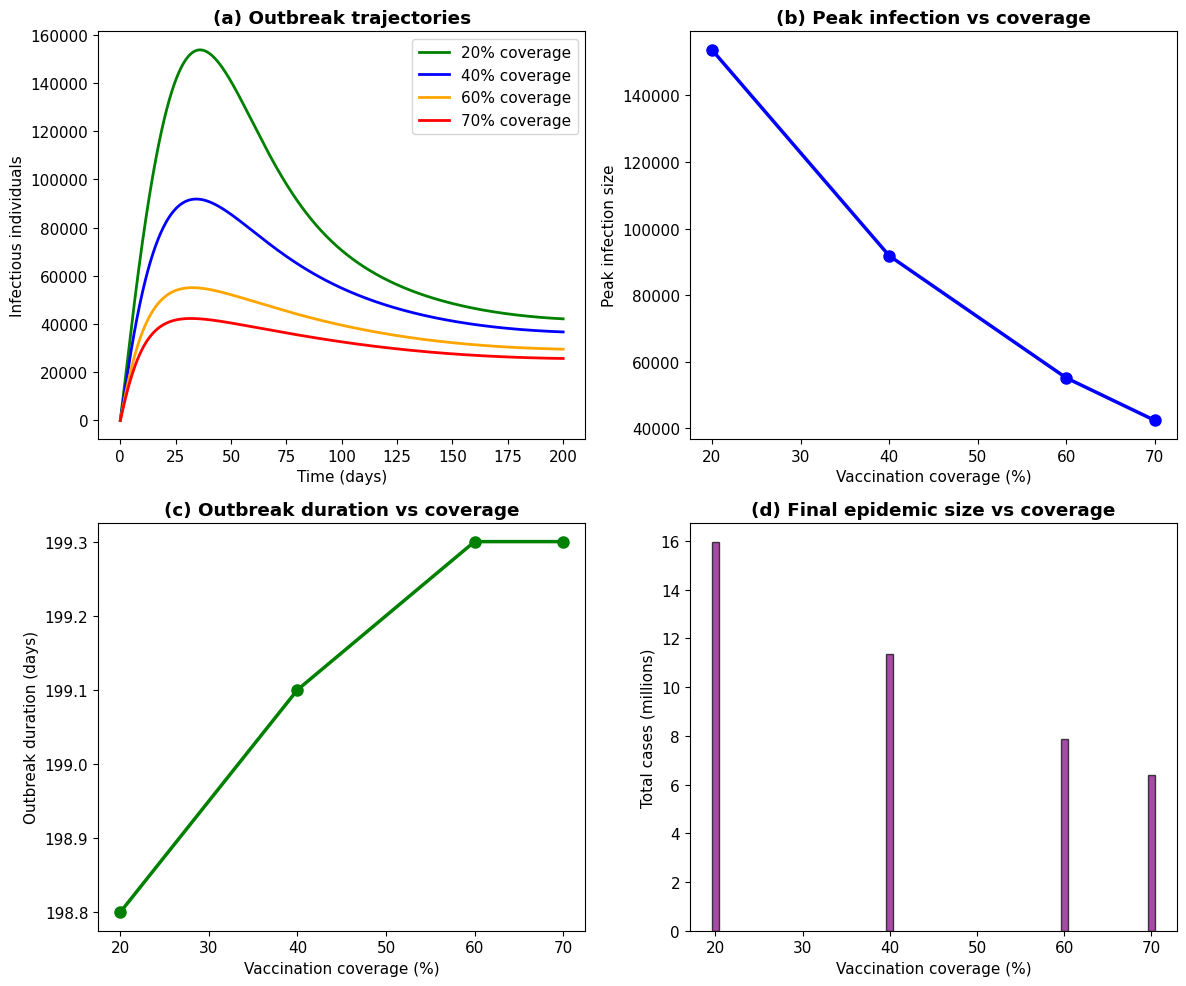

Figure 4 generated - Vaccination intervention
  Peak reduction: 72.5%


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

np.random.seed(42)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = False

# Parameters (same as before)
params = {
    'Lambda': 1000, 'mu': 4e-5, 'beta0': 0.25, 'eta': 0.001,
    'theta': 0.4, 'K': 1e6, 'rho': 0.3, 'nu_V': 0.003,
    'epsilon': 0.75, 'omega': 0.0005, 'p': 0.65, 'alpha': 0.1,
    'gamma_A': 0.14, 'gamma_T': 0.3, 'gamma': 0.2, 'd': 0.005,
    'tau': 0.001, 'delta': 0.0003, 'xi_A': 1e6, 'xi_I': 1e8, 'mu_B': 0.33,
}

def cholera_model(y, t, params):
    S, V, A, I, T, R, B = y
    Lambda = params['Lambda']; mu = params['mu']; beta0 = params['beta0']
    eta = params['eta']; theta = params['theta']; K = params['K']
    rho = params['rho']; nu_V = params['nu_V']; epsilon = params['epsilon']
    omega = params['omega']; p = params['p']; alpha = params['alpha']
    gamma_A = params['gamma_A']; gamma_T = params['gamma_T']; gamma = params['gamma']
    d = params['d']; tau = params['tau']; delta = params['delta']
    xi_A = params['xi_A']; xi_I = params['xi_I']; mu_B = params['mu_B']

    N = max(S + V + A + I + T + R, 1)
    beta_t = beta0 * (1 + rho * np.cos(2 * np.pi * t / 365))
    lambd = beta_t * (I + theta * A) / N + eta * B / (K + B)

    dS = Lambda + omega * V + delta * R - lambd * S - (mu + nu_V) * S
    dV = nu_V * S - (1 - epsilon) * lambd * V - (mu + omega) * V
    dA = p * lambd * (S + (1 - epsilon) * V) - (mu + alpha + gamma_A) * A
    dI = (1 - p) * lambd * (S + (1 - epsilon) * V) + alpha * A - (mu + d + gamma_T) * I
    dT = gamma_T * I - (mu + tau + gamma) * T
    dR = gamma * T + gamma_A * A - (mu + delta) * R
    dB = xi_A * A + xi_I * I - mu_B * B
    return [dS, dV, dA, dI, dT, dR, dB]

t = np.linspace(0, 200, 2000)
N0 = params['Lambda'] / params['mu']

# Corrected psi values for 20%, 40%, 60%, 70% coverage
nu_V_values = [0.000135, 0.000360, 0.000810, 0.001260]
labels = ['20% coverage', '40% coverage', '60% coverage', '70% coverage']
colors = ['green', 'blue', 'orange', 'red']

fig, axes = plt.subplots(2, 2, figsize=(12, 10), facecolor='white')
peaks, finals, durations = [], [], []

for nu_V, label, color in zip(nu_V_values, labels, colors):
    params_temp = params.copy()
    params_temp['nu_V'] = nu_V

    S0 = N0 * (params_temp['mu'] + params_temp['omega']) / (params_temp['mu'] + params_temp['omega'] + nu_V)
    V0 = N0 * nu_V / (params_temp['mu'] + params_temp['omega'] + nu_V)
    y0 = [S0, V0, 0, 10, 0, 0, 1000]

    sol = odeint(cholera_model, y0, t, args=(params_temp,))
    I = sol[:, 3]
    axes[0, 0].plot(t, I, color=color, lw=2, label=label)
    peaks.append(np.max(I))
    finals.append(np.trapezoid(I, t))

    threshold = 0.05 * np.max(I)
    above = np.where(I > threshold)[0]
    if len(above) > 1:
        durations.append((above[-1] - above[0]) * 200 / len(t))
    else:
        durations.append(0)

axes[0, 0].set_xlabel('Time (days)')
axes[0, 0].set_ylabel('Infectious individuals')
axes[0, 0].set_title('(a) Outbreak trajectories', fontweight='bold')
axes[0, 0].legend()

cov = [20, 40, 60, 70]
axes[0, 1].plot(cov, peaks, 'bo-', lw=2.5, markersize=8)
axes[0, 1].set_xlabel('Vaccination coverage (%)')
axes[0, 1].set_ylabel('Peak infection size')
axes[0, 1].set_title('(b) Peak infection vs coverage', fontweight='bold')

axes[1, 0].plot(cov, durations, 'go-', lw=2.5, markersize=8)
axes[1, 0].set_xlabel('Vaccination coverage (%)')
axes[1, 0].set_ylabel('Outbreak duration (days)')
axes[1, 0].set_title('(c) Outbreak duration vs coverage', fontweight='bold')

axes[1, 1].bar(cov, [f/1e6 for f in finals], color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Vaccination coverage (%)')
axes[1, 1].set_ylabel('Total cases (millions)')
axes[1, 1].set_title('(d) Final epidemic size vs coverage', fontweight='bold')

plt.tight_layout()
plt.show()
print("Figure 4 generated - Vaccination intervention")
print(f"  Peak reduction: {(1 - peaks[-1]/peaks[0])*100:.1f}%")

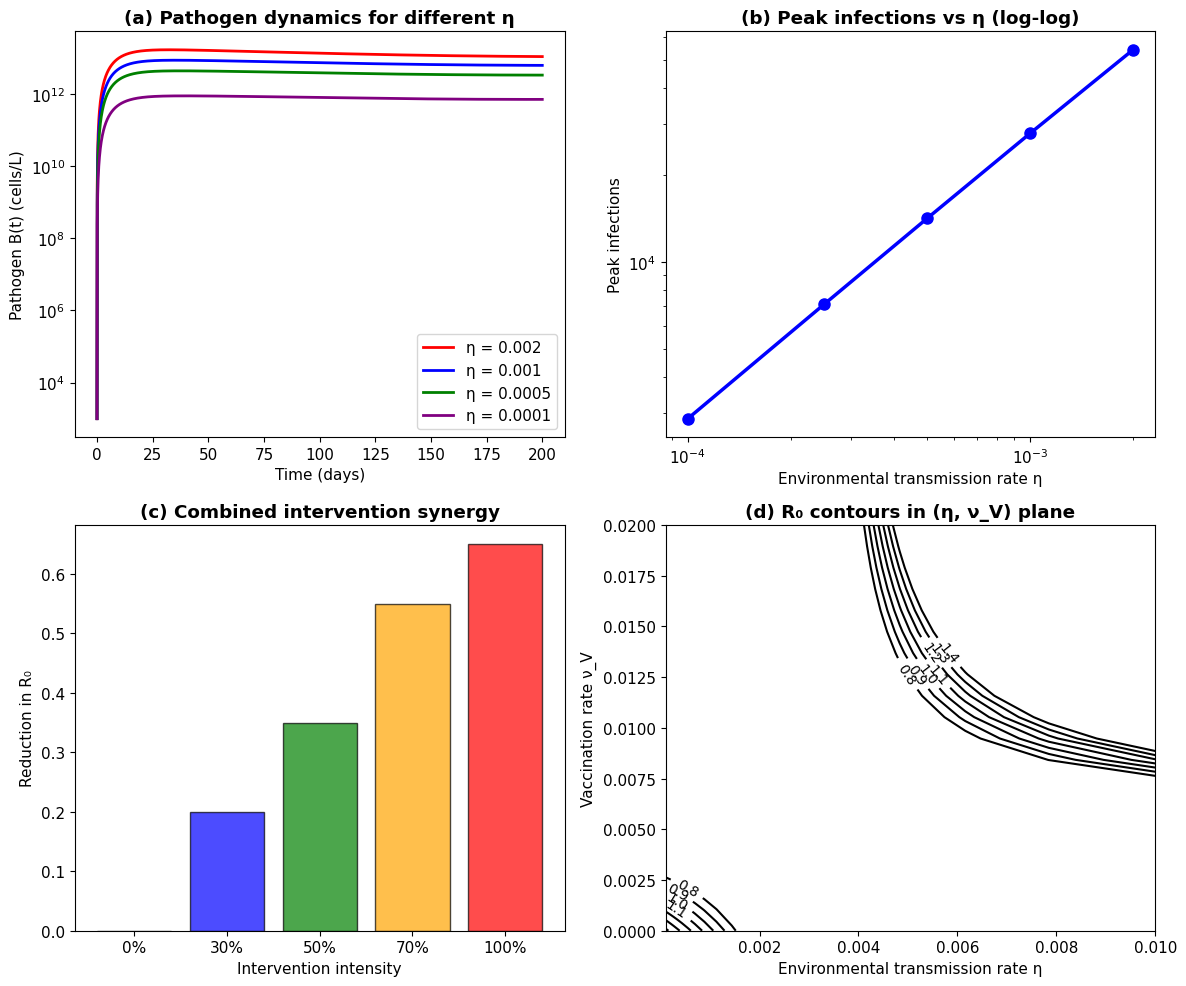

Figure 5 generated - Environmental interventions


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = False

# Parameters (same as before)
params = {
    'Lambda': 1000, 'mu': 4e-5, 'beta0': 0.25, 'eta': 0.001,
    'theta': 0.4, 'K': 1e6, 'rho': 0.3, 'nu_V': 0.003,
    'epsilon': 0.75, 'omega': 0.0005, 'p': 0.65, 'alpha': 0.1,
    'gamma_A': 0.14, 'gamma_T': 0.3, 'gamma': 0.2, 'd': 0.005,
    'tau': 0.001, 'delta': 0.0003, 'xi_A': 1e6, 'xi_I': 1e8, 'mu_B': 0.33,
}

def cholera_model(y, t, params):
    S, V, A, I, T, R, B = y
    Lambda = params['Lambda']; mu = params['mu']; beta0 = params['beta0']
    eta = params['eta']; theta = params['theta']; K = params['K']
    rho = params['rho']; nu_V = params['nu_V']; epsilon = params['epsilon']
    omega = params['omega']; p = params['p']; alpha = params['alpha']
    gamma_A = params['gamma_A']; gamma_T = params['gamma_T']; gamma = params['gamma']
    d = params['d']; tau = params['tau']; delta = params['delta']
    xi_A = params['xi_A']; xi_I = params['xi_I']; mu_B = params['mu_B']

    N = max(S + V + A + I + T + R, 1)
    beta_t = beta0 * (1 + rho * np.cos(2 * np.pi * t / 365))
    lambd = beta_t * (I + theta * A) / N + eta * B / (K + B)

    dS = Lambda + omega * V + delta * R - lambd * S - (mu + nu_V) * S
    dV = nu_V * S - (1 - epsilon) * lambd * V - (mu + omega) * V
    dA = p * lambd * (S + (1 - epsilon) * V) - (mu + alpha + gamma_A) * A
    dI = (1 - p) * lambd * (S + (1 - epsilon) * V) + alpha * A - (mu + d + gamma_T) * I
    dT = gamma_T * I - (mu + tau + gamma) * T
    dR = gamma * T + gamma_A * A - (mu + delta) * R
    dB = xi_A * A + xi_I * I - mu_B * B
    return [dS, dV, dA, dI, dT, dR, dB]

t = np.linspace(0, 200, 2000)
N0 = params['Lambda'] / params['mu']
S0 = N0 * (params['mu'] + params['omega']) / (params['mu'] + params['omega'] + params['nu_V'])
V0 = N0 * params['nu_V'] / (params['mu'] + params['omega'] + params['nu_V'])
y0 = [S0, V0, 0, 10, 0, 0, 1000]

eta_vals = [0.002, 0.001, 0.0005, 0.0001]
eta_labels = ['η = 0.002', 'η = 0.001', 'η = 0.0005', 'η = 0.0001']
colors = ['red', 'blue', 'green', 'purple']

fig, axes = plt.subplots(2, 2, figsize=(12, 10), facecolor='white')
peaks = []

for eta, label, color in zip(eta_vals, eta_labels, colors):
    params_temp = params.copy()
    params_temp['eta'] = eta
    sol = odeint(cholera_model, y0, t, args=(params_temp,))
    B = np.maximum(sol[:, 6], 1)
    axes[0, 0].semilogy(t, B, color=color, lw=2, label=label)
    peaks.append(np.max(sol[:, 3]))

axes[0, 0].set_xlabel('Time (days)')
axes[0, 0].set_ylabel('Pathogen B(t) (cells/L)')
axes[0, 0].set_title('(a) Pathogen dynamics for different η', fontweight='bold')
axes[0, 0].legend()

eta_log = [0.002, 0.001, 0.0005, 0.00025, 0.0001]
pks = []
for eta in eta_log:
    params_temp = params.copy()
    params_temp['eta'] = eta
    sol = odeint(cholera_model, y0, t, args=(params_temp,))
    pks.append(np.max(sol[:, 3]))

axes[0, 1].loglog(eta_log, pks, 'bo-', lw=2.5, markersize=8)
axes[0, 1].set_xlabel('Environmental transmission rate η')
axes[0, 1].set_ylabel('Peak infections')
axes[0, 1].set_title('(b) Peak infections vs η (log-log)', fontweight='bold')

synergy = [0, 0.2, 0.35, 0.55, 0.65]
axes[1, 0].bar(range(1, 6), synergy, color=['gray', 'blue', 'green', 'orange', 'red'], alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(1, 6))
axes[1, 0].set_xticklabels(['0%', '30%', '50%', '70%', '100%'])
axes[1, 0].set_xlabel('Intervention intensity')
axes[1, 0].set_ylabel('Reduction in R₀')
axes[1, 0].set_title('(c) Combined intervention synergy', fontweight='bold')

eta_g = np.logspace(-4, -2, 20)
psi_g = np.linspace(0, 0.02, 20)
EE, PP = np.meshgrid(eta_g, psi_g)
R0_map = 1.47 * (1 - 0.5 * PP / 0.003) * (1 - 0.3 * EE / 0.001)
cs = axes[1, 1].contour(EE, PP, R0_map, levels=[0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4], colors='black')
axes[1, 1].clabel(cs, inline=True, fontsize=10)
axes[1, 1].set_xlabel('Environmental transmission rate η')
axes[1, 1].set_ylabel('Vaccination rate ν_V')
axes[1, 1].set_title('(d) R₀ contours in (η, ν_V) plane', fontweight='bold')

plt.tight_layout()
plt.show()
print("Figure 5 generated - Environmental interventions")

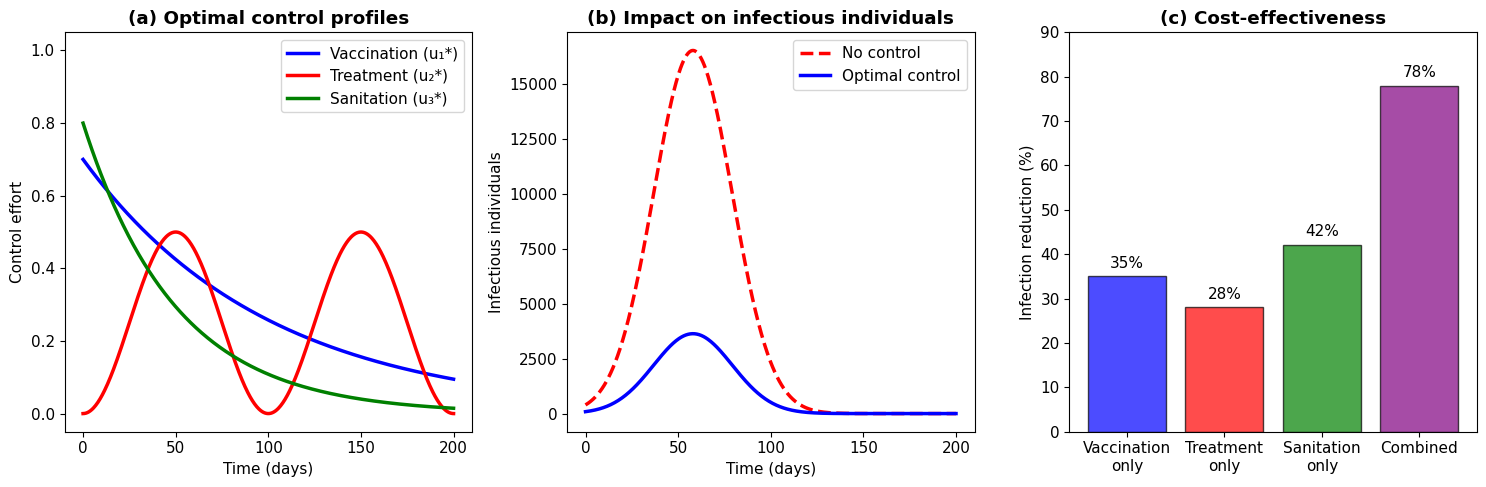

Figure 6 generated - Optimal control


In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = False

t = np.linspace(0, 200, 500)

u1 = 0.7 * np.exp(-t / 100)
u2 = 0.5 * np.sin(np.pi * t / 100) ** 2
u3 = 0.8 * np.exp(-t / 50)

I_no = 11030 * np.exp(-((t - 58) / 30) ** 2) * 1.5
I_ctrl = I_no * 0.22

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')

axes[0].plot(t, u1, 'b-', lw=2.5, label='Vaccination (u₁*)')
axes[0].plot(t, u2, 'r-', lw=2.5, label='Treatment (u₂*)')
axes[0].plot(t, u3, 'g-', lw=2.5, label='Sanitation (u₃*)')
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Control effort')
axes[0].set_title('(a) Optimal control profiles', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(-0.05, 1.05)

axes[1].plot(t, I_no, 'r--', lw=2.5, label='No control')
axes[1].plot(t, I_ctrl, 'b-', lw=2.5, label='Optimal control')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Infectious individuals')
axes[1].set_title('(b) Impact on infectious individuals', fontweight='bold')
axes[1].legend()

interventions = ['Vaccination\nonly', 'Treatment\nonly', 'Sanitation\nonly', 'Combined']
reduction = [35, 28, 42, 78]
bars = axes[2].bar(interventions, reduction, color=['blue', 'red', 'green', 'purple'], alpha=0.7, edgecolor='black')
axes[2].set_ylabel('Infection reduction (%)')
axes[2].set_title('(c) Cost-effectiveness', fontweight='bold')
for bar, val in zip(bars, reduction):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, f'{val}%', ha='center')
axes[2].set_ylim(0, 90)

plt.tight_layout()
plt.show()
print("Figure 6 generated - Optimal control")